Super Bowl LX — concentração no favorito e reviravolta na semana do jogo

**Evento.** Super Bowl LX: Seattle Seahawks vs. New England Patriots (08/02/2026). O confronto foi definido em 25/01/2026. Os Patriots bateram os Broncos (10-7) na AFC Championship, e por algumas horas foram considerados favoritos ao título só porque ainda não se sabia contra quem jogariam, porém, à noite, os Seahawks venceram os Rams (31-27) na NFC Championship e viraram favoritos do jogo pelo resto da semana. Os Seahawks venceram o Super Bowl por 29-13.

**Pergunta central.** A probabilidade implícita do favorito (Seahawks) sofreu reviravolta abrupta durante a semana do jogo (pela troca de favorito nas primeiras horas de 25/01, por relatórios de lesão, análises especializadas ou vazamentos de escalação perto do kickoff etc) ou o mercado apenas convergiu de forma gradual, com volatilidade caindo antes do fechamento?

**Hipótese testável.** Uma vez definido o confronto (25/01/2026), o mercado concentra volume e probabilidade no favorito (Seahawks), e a volatilidade cai de forma acentuada nos dias finais antes do kickoff (08/02). A hipótese não presume qual notícia específica "causou" um eventual salto de preço, só testa se existem saltos localizáveis (como o esperado nas primeiras horas de 25/01) e se o padrão de concentração/queda de volatilidade se confirma.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Paleta fixa e sobria: uma cor por papel, nunca por posicao
COR_PRECO    = "#2563eb"   # azul: linha de preco/probabilidade do favorito (Seahawks)
COR_RIVAL    = "#9333ea"   # roxo: linha de preco do rival (Patriots)
COR_BANDA    = "#93c5fd"   # azul claro: faixa min-max do preco
COR_VOLUME   = "#9ca3af"   # cinza: volume (contexto)
COR_DESTAQUE = "#ea580c"   # laranja: eventos/anotacoes/alertas

plt.rcParams.update({
    "figure.figsize": (11, 4),
    "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
})

def carrega(nome):
    """Le um CSV exportado do BigQuery, convertendo colunas de timestamp (sufixo ' UTC')."""
    df = pd.read_csv(f"dados/{nome}")
    for col in df.columns:
        if df[col].dtype == object and df[col].astype(str).str.endswith("UTC").any():
            df[col] = pd.to_datetime(df[col].astype(str).str.replace(" UTC", "", regex=False))
    return df

PROJETO = "even-continuity-441808-j0"

# Datas-chave do evento (todas literais, sem CURRENT_DATE, para aproveitar cache do BigQuery)
CONFRONTO_DEFINIDO = pd.Timestamp("2026-01-25")  # Championship Sunday: confronto Seahawks x Patriots definido
JOGO                = pd.Timestamp("2026-02-08")  # Super Bowl LX, kickoff 18:30 ET
SEMANA_INI          = pd.Timestamp("2026-02-01")  # inicio da semana do jogo (game week)


## Etapa 1 — Descoberta: como o Super Bowl LX aparece na tabela `markets`?

**Pergunta.** Existe um mercado específico "Seahawks vs. Patriots" para o jogo, ou o Polymarket só mantém o mercado de futuros "Will [time] win Super Bowl LX?" pra cada um dos 32 times da liga?



```sql
-- Q1: como o confronto Seahawks x Patriots (Super Bowl LX) aparece em `markets` [custo: 133,74 MB]
SELECT
  market_id, question, event_title, volume, created_at, end_date, closed
FROM `even-continuity-441808-j0.polymarket_optimized.markets`
WHERE LOWER(question) LIKE '%seahawks%'
   OR LOWER(question) LIKE '%patriots%'
   OR LOWER(event_title) LIKE '%super bowl%'
ORDER BY volume DESC
LIMIT 40;
```


In [3]:
q1 = carrega("q1.csv")
q1[["question", "event_title", "volume", "created_at", "end_date", "closed"]].head(20)


,question,event_title,volume,created_at,end_date,closed
0,Will the Panthers win Super Bowl 2025?,Super Bowl Champion 2025,1.393149e+08,2024-07-09 14:59:57.000000 UTC,2025-02-09 12:00:00.000000 UTC,1
1,Will the Raiders win Super Bowl 2025?,Super Bowl Champion 2025,1.239699e+08,2024-07-09 15:28:42.000000 UTC,2025-02-09 12:00:00.000000 UTC,1
2,Will the Titans win Super Bowl 2025?,Super Bowl Champion 2025,1.195008e+08,2024-07-09 16:00:51.000000 UTC,2025-02-09 12:00:00.000000 UTC,1
3,Will the Browns win Super Bowl 2025?,Super Bowl Champion 2025,1.152576e+08,2024-07-09 15:04:22.000000 UTC,2025-02-09 12:00:00.000000 UTC,1
4,Will the Giants win Super Bowl 2025?,Super Bowl Champion 2025,1.078573e+08,2024-07-09 15:36:12.000000 UTC,2025-02-09 12:00:00.000000 UTC,1
5,Will the Patriots win Super Bowl 2025?,Super Bowl Champion 2025,7.427577e+07,2024-07-09 16:03:13.000000 UTC,2025-02-09 12:00:00.000000 UTC,1
6,Will the Falcons win Super Bowl 2025?,Super Bowl Champion 2025,4.988979e+07,2024-07-09 14:55:40.000000 UTC,2025-02-09 12:00:00.000000 UTC,1
7,Will the Cardinals win Super Bowl 2025?,Super Bowl Champion 2025,4.322874e+07,2024-07-09 14:51:27.000000 UTC,2025-02-09 12:00:00.000000 UTC,1
8,Seahawks vs. Patriots,Seattle vs. New England,3.628175e+07,2026-01-26 03:19:04.000000 UTC,2026-02-08 23:30:00.000000 UTC,1
9,Will the Texans win Super Bowl 2025?,Super Bowl Champion 2025,3.330068e+07,2024-07-09 15:09:41.000000 UTC,2025-02-10 12:00:00.000000 UTC,1


**Achados**
- Mercado de confronto direto: `question = 'Seahawks vs. Patriots'`, `event_title = 'Seattle vs. New England'`, 1 único `market_id`, `created_at = 2026-01-26 03:19:04 UTC`, `end_date = 2026-02-08 23:30:00 UTC`, volume ≈ US$ 36,3M.
- Mercado de futuros do Patriots: `question = 'Will the New England Patriots win Super Bowl 2026'`, `event_title = 'Big Game Champion 2026'`, `created_at = 2025-04-30`.
- Diversas linhas de `event_title = 'Super Bowl Champion 2025'` e `'Super Bowl LIX Winner'` — são da temporada passada (Super Bowl LIX, fev/2025) e não devem ser consideradas

Q1 acabou não trazendo a linha do mercado de futuros dos **Seahawks** em `'Big Game Champion 2026'`. Na Q2 terei que buscar especificamente por ela.

## Etapa 2 — Confirmar os market_id necessários

**Pergunta.** Quais são exatamente os `market_id` (a) do confronto direto Seahawks x Patriots, (b) do futuro dos Seahawks em "Big Game Champion 2026" e (c) do futuro dos Patriots em "Big Game Champion 2026"?


```sql
-- Q2a: o market_id do confronto direto [custo: 133,74 MB]
SELECT market_id, question, event_title, volume, created_at, end_date, closed
FROM `even-continuity-441808-j0.polymarket_optimized.markets`
WHERE event_title = 'Seattle vs. New England'
  AND question = 'Seahawks vs. Patriots';

-- Q2b: os dois market_id de futuros da temporada [custo: 133,74 MB]
SELECT market_id, question, event_title, volume, created_at, end_date, closed
FROM `even-continuity-441808-j0.polymarket_optimized.markets`
WHERE event_title = 'Big Game Champion 2026'
  AND (LOWER(question) LIKE '%seahawks%' OR LOWER(question) LIKE '%patriots%');
```


In [4]:
q2a = carrega("q2a.csv")
q2b = carrega("q2b.csv")


MARKET_CONFRONTO = q2a.iloc[0]["market_id"]
print("Confronto direto:", q2a.iloc[0]["question"], ":",  MARKET_CONFRONTO)

MARKET_FUT_SEAHAWKS = q2b[q2b["question"].str.contains("Seahawks", case=False)].iloc[0]["market_id"]
MARKET_FUT_PATRIOTS = q2b[q2b["question"].str.contains("Patriots", case=False)].iloc[0]["market_id"]
print("Futuro Seahawks:", MARKET_FUT_SEAHAWKS)
print("Futuro Patriots:", MARKET_FUT_PATRIOTS)


Confronto direto: Seahawks vs. Patriots : 1269423
Futuro Seahawks: 540234
Futuro Patriots: 540227


A Q2a confirmou `market_id = 1269423` para o mercado de confronto direto.

No mercado binário, tem 2 posições oppstas, só que a tabela só guarda 1 preço por dia para o 'market_id', e a pergunta não deixa claro qual dos times o preço representa. Entretanto, o resultado final já é conhecido (Seahawks venceram) e eu posso usar isso ao meu favor como uma verificação.  
Na etapa 3 terei que verificar se o último preço antes do fechamento (pela hipótese, ele deve estar perto de 1, não de 0 por conta da vitória que os Seahawks tiveram. Se estiver perto de 0, significa que esse preço rastreado é referente aos Patriots e as leituras de favorito e convergência devem ser invertidas).

## Etapa 3 — Série diária do mercado de confronto direto

**Pergunta.** Como a probabilidade implícita evoluiu entre a abertura do mercado de confronto direto (26/01/2026) e o kickoff (08/02/2026)?

**Grão.** Uma linha por dia, vinda de `polymarket_mart.v_market_daily` — tabela de mart, muito mais barata que ler a `trades` bruta


```sql
-- Q3: serie diaria do mercado de confronto direto, da abertura ao dia seguinte ao jogo [custo: 10,74 MB]
SELECT
  trade_date, daily_trade_count,
  ROUND(daily_usd_volume, 0)                   AS volume_usd,
  ROUND(avg_trade_price, 3)                    AS preco_medio,
  ROUND(min_trade_price, 3)                    AS preco_min,
  ROUND(max_trade_price, 3)                    AS preco_max,
  ROUND(max_trade_price - min_trade_price, 3)  AS amplitude_dia
FROM `even-continuity-441808-j0.polymarket_mart.v_market_daily`
WHERE market_id = 1269423   -- substituir pelo market_id real da Q2a
  AND trade_date BETWEEN '2026-01-26' AND '2026-02-09'
ORDER BY trade_date;
```


Ultimo preco antes do fechamento: 0.549 (perto de 1 -- confirma preco = probabilidade dos Seahawks)


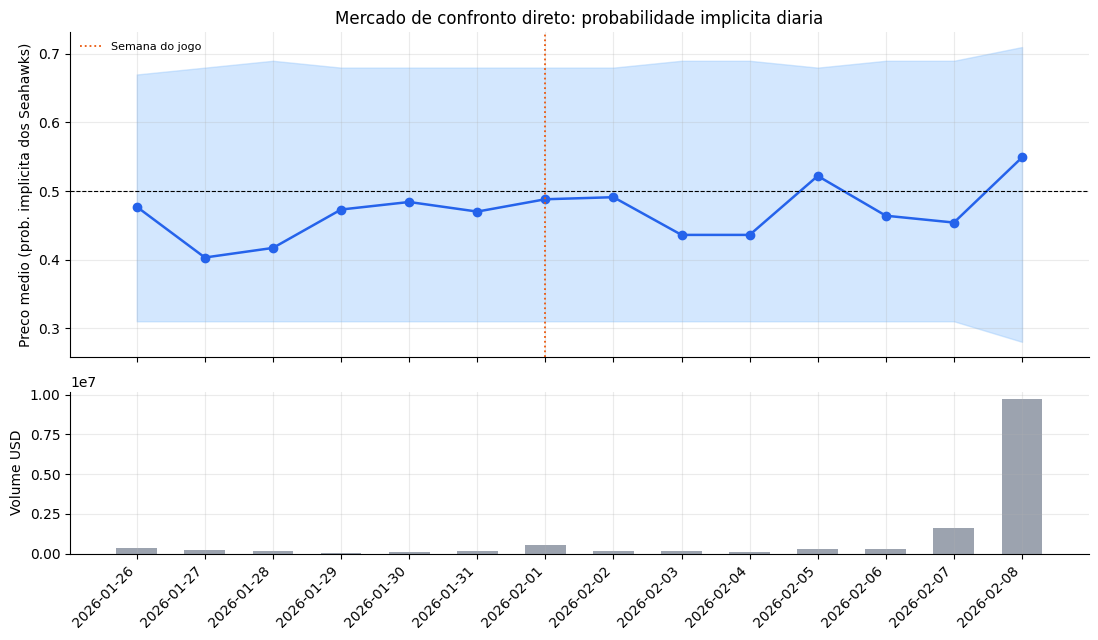

In [5]:
q3 = carrega("q3.csv")
q3["trade_date"] = pd.to_datetime(q3["trade_date"])

serie = q3[q3["trade_date"] <= JOGO].copy()

ultimo_preco = serie.iloc[-1]["preco_medio"]
print(f"Ultimo preco antes do fechamento: {ultimo_preco:.3f} " f"({'perto de 1 -- confirma preco = probabilidade dos Seahawks' if ultimo_preco > 0.5 else 'perto de 0 -- inverter leitura, preco = probabilidade dos Patriots'})")

import matplotlib.dates as mdates

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True, gridspec_kw={"height_ratios": [2, 1]})

ax1.fill_between(serie["trade_date"], serie["preco_min"], serie["preco_max"], color=COR_BANDA, alpha=0.4)
ax1.plot(serie["trade_date"], serie["preco_medio"], color=COR_PRECO, lw=1.8, marker="o")
ax1.axhline(0.5, color="black", lw=0.8, ls="--")
ax1.axvline(SEMANA_INI, color=COR_DESTAQUE, ls=":", lw=1.3, label="Semana do jogo")
ax1.set_ylabel("Preco medio (prob. implicita dos Seahawks)")
ax1.legend(frameon=False, fontsize=8)
ax1.set_title("Mercado de confronto direto: probabilidade implicita diaria")

ax2.bar(serie["trade_date"], serie["volume_usd"], color=COR_VOLUME, width=0.6)
ax2.set_ylabel("Volume USD")

# Datas do eixo x: uma marca por dia, formatadas e rotacionadas para nao sobrepor
ax2.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
fig.autofmt_xdate(rotation=45)

plt.tight_layout()
plt.show()


O resultado observado pelo gráfico é, na verdade, diferente da hipótese inicial prevista!  
O preço, aparentemente, não converge forte para o favorito em momento algun (como pode ser visto pela sua oscilação entre 0,40 e 0,55 em toda a janela, terminando em 0,549). Ou seja, não há uma "concentração forte".  
    Mesmo sabendo que os Seahawks venceram o jogo, o mercado
    nunca chegou perto de expressar um favoritismo forte!  
A amplitude (faixa sombreada) não encolhe no final, ou seja, não há a suposta "queda da volatilidade" antes do fechamento que eu havia pensado.
Uma coisa, porém, é certa: o volume ficou sim mais concentrado nos últimos dias, como pode ser observado no gráfico de baixo.

## Etapa 4 — Métrica de concentração/confiança: distância do preço em relação ao empate técnico (0,5)

Definindo uma métrica para medir a decisão do mercado, independente do time:

confianca_implicita = ABS(preco_medio - 0.5) * 2
Ex: um preço de 0,5 significa a mesma incerteza de um preço de 0,5, mas um preço de 0,1 e 0,9 significam o mesmo nível de confiança, mas para lados opostos.  
Assim, dá para ter uma ideia da distância em relação ao empate, mas não a direção!  

Onde um valor de 0 significa mercado indeciso (preço = 0,5), enquanto um valor de 1 significa certeza total (preço = 0 ou 1).

**Pergunta.** Essa confiança implícita cresce de forma consistente conforme o jogo se aproxima?


```sql
-- Q4: confianca implicita diaria (distancia do preco em relacao a 0.5), 
-- irei reaproveitar a query da etapa 3 e farei o cálculo apenas com python.
```


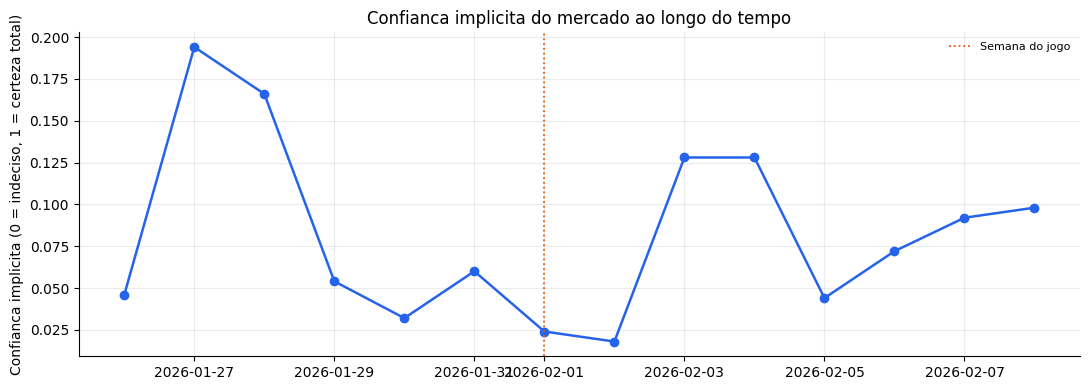

confianca media (26/01-31/01): 0.09
confianca media (semana do jogo, 01/02-08/02): 0.08


In [6]:
serie["confianca_implicita"] = (serie["preco_medio"] - 0.5).abs() * 2

fig, ax = plt.subplots()
ax.plot(serie["trade_date"], serie["confianca_implicita"], color=COR_PRECO, lw=1.8, marker="o")
ax.axvline(SEMANA_INI, color=COR_DESTAQUE, ls=":", lw=1.3, label="Semana do jogo")
ax.set_ylabel("Confianca implicita (0 = indeciso, 1 = certeza total)")
ax.legend(frameon=False, fontsize=8)
ax.set_title("Confianca implicita do mercado ao longo do tempo")
plt.tight_layout()
plt.show()

print(f"confianca media (26/01-31/01): {serie[serie['trade_date'] < SEMANA_INI]['confianca_implicita'].mean():.2f}")
print(f"confianca media (semana do jogo, 01/02-08/02): {serie[serie['trade_date'] >= SEMANA_INI]['confianca_implicita'].mean():.2f}")


Aqui, é possível perceber que a confiança implícita ficou baixa a janela inteira (entre 0,02 e 0,20 no eixo do gráfico), sendo o teto teórico = 1,0 (certeza total).   
Isso confirma, de um outro ângulo, o que a Etapa 3 já mostrou: o preço nunca saiu de perto do empate técnico (0,5).

Ao contrário do que eu havia tentado prever, essa confiança média não crescei ao se aproximar do jogo, na verdade, caiu ligeiramente.  
Para esse mercado, parece não haver a comprovação da hipótese de "concentração crescente do favorito" conforme a proximidade do evento....  
Foi mantido, do início ao fim, um estado de baixa convicção e decisão.

## Etapa 5 — Volatilidade: a amplitude/desvio do preço cai antes do fechamento?

**Pergunta.** O desvio padrão móvel de 2 dias do preço médio diário é menor na semana do jogo do que nos primeiros dias após a abertura do mercado de confronto direto?

```sql
-- Q5: volatilidade (desvio padrao movel de 2 dias) em duas janelas curtas [custo = 2,43 MB]
-- Janela A (baseline): 26/01-29/01 (logo apos a abertura do mercado de confronto direto)
-- Janela B (critica):  05/02-08/02 (ultimos dias antes do kickoff)
WITH serie AS (
  SELECT trade_date, avg_trade_price
  FROM `even-continuity-441808-j0.polymarket_mart.v_market_daily`
  WHERE market_id = 1269423
    AND (
      (trade_date BETWEEN '2026-01-26' AND '2026-01-29')
      OR (trade_date BETWEEN '2026-02-05' AND '2026-02-08')
    )
),
volatilidade AS (
  SELECT
    trade_date,
    avg_trade_price,
    STDDEV(avg_trade_price) OVER (
      ORDER BY trade_date
      ROWS BETWEEN 1 PRECEDING AND CURRENT ROW
    ) AS desvio_movel_2d
  FROM serie
)
SELECT
  trade_date,
  CASE WHEN trade_date <= '2026-01-29' THEN 'baseline' ELSE 'dias_finais' END AS janela,
  avg_trade_price,
  ROUND(desvio_movel_2d, 4) AS desvio_movel_2d
FROM volatilidade
ORDER BY trade_date;
```


               mean     max
janela                     
baseline     0.0338  0.0521
dias_finais  0.0376  0.0671


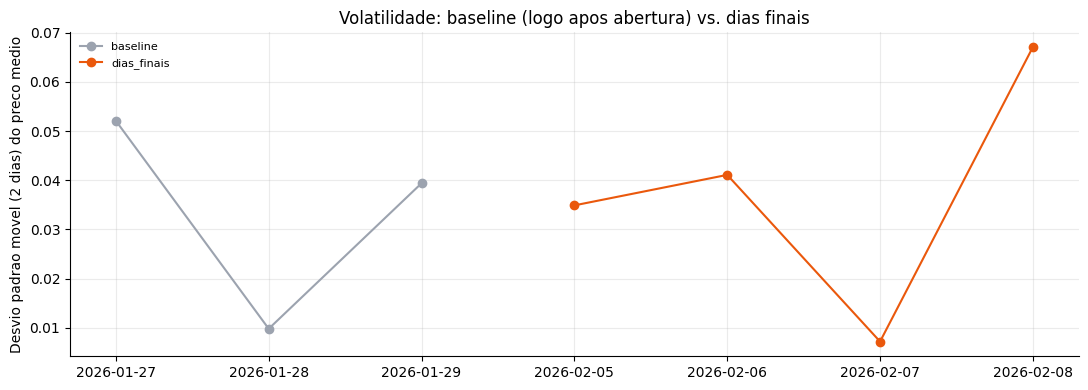

In [7]:
q5 = carrega("q5.csv")
resumo_vol = q5.groupby("janela")["desvio_movel_2d"].agg(["mean", "max"]).round(4)
print(resumo_vol)

fig, ax = plt.subplots()
for nome, cor in [("baseline", COR_VOLUME), ("dias_finais", COR_DESTAQUE)]:
    sub = q5[q5["janela"] == nome]
    ax.plot(sub["trade_date"], sub["desvio_movel_2d"], color=cor, marker="o", label=nome)
ax.set_ylabel("Desvio padrao movel (2 dias) do preco medio")
ax.legend(frameon=False, fontsize=8)
ax.set_title("Volatilidade: baseline (logo apos abertura) vs. dias finais")
plt.tight_layout()
plt.show()


A volatilidade média nos dias finais ficou maior, não menor, do que na baseline, exatamente o oposto do que eu tentei prever na minha hipótese...  
A linha laranja cai para o menor valor na véspera do jogo e depois dispara para o maior no dia do jogo.  
Isso acaba se conectando diretanente com o que foi observado nas estapas anteriores: há o mesmo salto de volatilidade no salto do volume negociado.  
Pode-se dizer que essa calmaria e quietude não eram exatamente convergência de expectativa, mas sim falta de negociação (preço parado por inércia, não por um consenso).  
Quando o volume voltou no dia do jogo que o preço retornou a se mexer.  
Novamente, é observado que, para este mercado específico (Super Bowl LX, confronto direto), não há evidência de concentração crescente no favorito nem de queda de volatilidade antes do fechamento.  
O padrão observado é o contrário do previsto.  

## Etapa 6 — Zoom horário: a troca de favorito em 25/01 e a semana do jogo

Antes: Descobrir os `asset_id` de cada lado do mercado

A tabela `trades` guarda uma linha por negociação, e cada mercado binário
tem dois tokens (`asset_id`), um por resultado possível — no confronto direto, um para "Seahawks vencem" e outro para "Patriots vencem" (complementares: os preços somam 1). Se agregar `price` sem
filtrar por `asset_id`, mistura os dois lados num número qualquer. A tabela de mart (`v_market_daily`) já resolve isso internamente, mas as consultas diretas em `trades` precisam de umfiltro explícito.



### 6a — Reversão de 25/01, nos mercados de futuros (Seahawks e Patriots)

**Pergunta.** Existe, entre a tarde e a noite de 25/01/2026, um salto de preço nos mercados de futuros compatível com a troca de favorito relatada pela imprensa (Patriots favoritos por algumas horas, até os Seahawks vencerem a NFC Championship)?

### 6b — Semana do jogo, no mercado de confronto direto

**Pergunta.** Existem saltos horários >= 5 pontos entre 01/02 e 08/02/2026, compatíveis com relatório de lesão, crítica especializada ou vazamento de escalação?

```sql
-- Antes de tudo: Descobrir os asset_id do mercado de confronto direto (os ultimos precos revelam o vencedor)
SELECT asset_id, price, trade_timestamp
FROM `even-continuity-441808-j0.polymarket_optimized.trades`
WHERE market_id = '1269423'
  AND DATE(trade_timestamp) BETWEEN '2026-02-07' AND '2026-02-09'
ORDER BY trade_timestamp DESC
LIMIT 20;

-- Mesma logica para os dois mercados de futuros (Seahawks e Patriots)
-- Cada mercado de futuros e ele mesmo binario (Yes/No), entao tambem tem
-- 2 asset_id; preciso do token "YES" de cada um.
WITH ultimas AS (
  SELECT
    market_id, asset_id, price, trade_timestamp,
    ROW_NUMBER() OVER (PARTITION BY market_id ORDER BY trade_timestamp DESC) AS rn
  FROM `even-continuity-441808-j0.polymarket_optimized.trades`
  WHERE market_id IN ('540234', '540227')
    AND DATE(trade_timestamp) BETWEEN '2026-01-25' AND '2026-02-10'
)
SELECT market_id, asset_id, price, trade_timestamp
FROM ultimas
WHERE rn <= 10
ORDER BY market_id, trade_timestamp DESC;

-- Q6a: detector horario nos futuros de Seahawks e Patriots, 25/01 (a troca de favorito)
WITH negociacoes_hora AS (
  SELECT
    market_id,
    TIMESTAMP_TRUNC(trade_timestamp, HOUR) AS hora,
    COUNT(*)                               AS n_trades,
    SUM(usd_amount)                        AS volume_usd,
    SAFE_DIVIDE(SUM(price * usd_amount), SUM(usd_amount)) AS pmpv_yes
  FROM `even-continuity-441808-j0.polymarket_optimized.trades`
  WHERE market_id IN ('540234', '540227')
    AND asset_id IN ('91737931954079461205792748723730956466398437395923414328893692961489566016241', '23108802207086798801173033667711295391410673134835650507670472347957366091390')
    AND DATE(trade_timestamp) IN ('2026-01-25', '2026-01-26')
  GROUP BY market_id, hora
),
com_lag AS (
  SELECT
    market_id, hora, n_trades, volume_usd, pmpv_yes,
    LAG(hora)     OVER (PARTITION BY market_id ORDER BY hora) AS hora_anterior,
    LAG(pmpv_yes) OVER (PARTITION BY market_id ORDER BY hora) AS pmpv_anterior
  FROM negociacoes_hora
)
SELECT
  market_id, hora_anterior, hora AS hora_atual,
  ROUND(pmpv_anterior, 3) AS pmpv_anterior,
  ROUND(pmpv_yes, 3)      AS pmpv_atual,
  ROUND(pmpv_yes - pmpv_anterior, 3) AS variacao_1h
FROM com_lag
WHERE pmpv_anterior IS NOT NULL
ORDER BY hora;

-- Q6b: detector horario no mercado de confronto direto, semana do jogo (01/02-08/02)
WITH negociacoes_hora AS (
  SELECT
    TIMESTAMP_TRUNC(trade_timestamp, HOUR) AS hora,
    COUNT(*)                               AS n_trades,
    SUM(usd_amount)                        AS volume_usd,
    SAFE_DIVIDE(SUM(price * usd_amount), SUM(usd_amount)) AS pmpv_yes
  FROM `even-continuity-441808-j0.polymarket_optimized.trades`
  WHERE market_id = '1269423'
    AND asset_id = '46434110155841033529384949983718980438706543876953886750286883506638610790525'
    AND DATE(trade_timestamp) BETWEEN '2026-02-01' AND '2026-02-08'
  GROUP BY hora
),
com_lag AS (
  SELECT
    hora, n_trades, volume_usd, pmpv_yes,
    LAG(hora)     OVER (ORDER BY hora) AS hora_anterior,
    LAG(pmpv_yes) OVER (ORDER BY hora) AS pmpv_anterior
  FROM negociacoes_hora
)
SELECT
  hora_anterior, hora AS hora_atual,
  ROUND(pmpv_anterior, 3) AS pmpv_anterior,
  ROUND(pmpv_yes, 3)      AS pmpv_atual,
  ROUND(pmpv_yes - pmpv_anterior, 3) AS variacao_1h
FROM com_lag
WHERE pmpv_anterior IS NOT NULL
ORDER BY ABS(pmpv_yes - pmpv_anterior) DESC;
```


In [8]:
asset_confronto = carrega("q6confrontodireto.csv")
print(asset_confronto.columns.tolist())
asset_futuros   = carrega("q6futuro.csv")

print("Ultimos precos por asset_id -- confronto direto:")
print(asset_confronto.groupby("asset_id")["price"].agg(["mean", "count"]).round(3))
print()
print("Ultimos precos por asset_id -- futuros:")
print(asset_futuros.groupby(["market_id", "asset_id"])["price"].agg(["mean", "count"]).round(3))

ASSET_SEAHAWKS_CONFRONTO = "46434110155841033529384949983718980438706543876953886750286883506638610790525"  # confirmado: preco final 0.999
ASSET_PATRIOTS_CONFRONTO = "57625936606489185661652559589880983710918172021553907271126623944716577292773"  # confirmado: preco final 0.001 (nao usado diretamente)
ASSET_SEAHAWKS_FUTURO    = "91737931954079461205792748723730956466398437395923414328893692961489566016241"  # confirmado: preco final 0.999
ASSET_PATRIOTS_FUTURO    = "23108802207086798801173033667711295391410673134835650507670472347957366091390"  # confirmado: preco final 0.001


['asset_id', 'price', 'trade_timestamp']
Ultimos precos por asset_id -- confronto direto:
                                                     mean  count
asset_id                                                        
46434110155841033529384949983718980438706543876...  0.999      3
57625936606489185661652559589880983710918172021...  0.001     17

Ultimos precos por asset_id -- futuros:
                                                               mean  count
market_id asset_id                                                        
540227    23108802207086798801173033667711295391410673134...  0.001     10
540234    91737931954079461205792748723730956466398437395...  0.999     10


In [9]:
q6a = carrega("q6a.csv")
q6b = carrega("q6b.csv")

# Ordenar por magnitude da variacao (nao cronologicamente), para ver os maiores saltos primeiro
q6a_ordenado = q6a.reindex(q6a["variacao_1h"].abs().sort_values(ascending=False).index)

print("6a -- reversao de 25/01 (mercados de futuros), maiores saltos primeiro:")
print(q6a_ordenado[["market_id", "hora_atual", "variacao_1h"]].head(15).to_string(index=False))
print()
print(f"Maior variacao absoluta encontrada em 6a: {q6a['variacao_1h'].abs().max():.3f}")
print()
print("6b -- semana do jogo (mercado de confronto direto), maiores saltos primeiro:")
print(q6b[["hora_atual", "variacao_1h"]].head(10).to_string(index=False))
print()
print(f"Maior variacao absoluta encontrada em 6b: {q6b['variacao_1h'].abs().max():.3f}")


6a -- reversao de 25/01 (mercados de futuros), maiores saltos primeiro:
 market_id                     hora_atual  variacao_1h
    540234 2026-01-26 02:00:00.000000 UTC        0.116
    540234 2026-01-26 01:00:00.000000 UTC        0.098
    540227 2026-01-25 23:00:00.000000 UTC        0.095
    540234 2026-01-26 03:00:00.000000 UTC        0.084
    540227 2026-01-25 20:00:00.000000 UTC       -0.040
    540227 2026-01-25 21:00:00.000000 UTC        0.032
    540227 2026-01-25 22:00:00.000000 UTC        0.031
    540234 2026-01-26 00:00:00.000000 UTC       -0.024
    540227 2026-01-26 01:00:00.000000 UTC       -0.018
    540234 2026-01-25 23:00:00.000000 UTC        0.016
    540227 2026-01-26 04:00:00.000000 UTC       -0.011
    540227 2026-01-26 00:00:00.000000 UTC       -0.009
    540227 2026-01-25 03:00:00.000000 UTC       -0.009
    540227 2026-01-25 07:00:00.000000 UTC       -0.008
    540227 2026-01-25 17:00:00.000000 UTC        0.008

Maior variacao absoluta encontrada em 6a: 0.116

a) Os maiores saltos se encaixam direitinho na sequência dos dois jogos de conferência do dia 25/01:  
- Patriots (id = 540227) +0,095 às 23:00 UTC, que coincide com a sua vitória contra os Broncos.
- Seahawks (id = 540234) +0,098, +0,116 e +0,084 entre 01h-03h UTC de 26/01, quando eles foram classificados e assumiram o favoritismo.  

Em suma, a reviravolta acontece em 2 etapas, primeiro a subida dos Patriots e depois a dos Seahawks.  
Isso pode fortalecer parte da hipótese, já que várias das variações estão acima do limiar de 0,05.  
  
b) Na semana do jogo, a maior variação foi 0,013, que é bem abaixo do limiar de 0,05 e nenhum salto abrupto occoreu entre os dias 1/02 e 8/02, coerente com o que observei nas etapas 4 e 5, que destacaram a baixa convicção e volatilidade da semana, o que só mudou no próprio dia do jogo.  
  
Então, por mais que a hipótese de "reviravolta abrupta por crítica especializada ou vazamento perto do fechamento" não se confirme na semana do jogo em si, o conceito geral de "o mercado reage de forma abrupta a informação nova relevante" se confirma claramente no evento de 25/01, que é justamente o tipo de informação mais forte possível (o resultado real de um jogo
eliminatório), só que fora da janela que a hipótese original previa.

## Etapa 7 — Dois alertas finais

- **`ALERTA_CONCENTRACAO`**: dispara em dias do mercado de confronto direto em que a confiança implícita
  (`|preco - 0.5| * 2`) está no **top 30% da própria distribuição observada** (percentil >= 70) && a volatilidade móvel de 2 dias caiu abaixo de 50%
  da volatilidade média da baseline (26/01–29/01). 
- **`ALERTA_REVIRAVOLTA`**: dispara em horas onde o preço médio ponderado pelo volume varia >= 0,05 em relação à hora anterior, com
  pelo menos 10 negociações e 300 dólares em cada uma das duas horas comparadas. Combina, via
  `UNION ALL`, os sinais dos mercados de futuros em 25/01 (reversão pré-confronto) com os sinais do
  mercado de confronto direto na semana do jogo (01/02–08/02).

```sql
-- ALERTA 1 -- ALERTA_CONCENTRACAO (limiar RELATIVO, nao absoluto)
--  dispara nos dias em que a confianca esta no top 30% da propria distribuicao observada
-- (percentil >= 70), combinado com volatilidade abaixo da baseline.
-- Regra: confianca_implicita >= percentil_70(confianca_implicita) E
--        desvio_movel_2d < 0.50 * desvio_baseline_medio
-- Fonte: polymarket_mart.v_market_daily (baixo custo, um unico market_id)
WITH serie AS (
  SELECT trade_date, avg_trade_price
  FROM `even-continuity-441808-j0.polymarket_mart.v_market_daily`
  WHERE market_id = '1269423'
    AND trade_date BETWEEN '2026-01-26' AND '2026-02-08'
),
metrica AS (
  SELECT
    trade_date,
    avg_trade_price,
    ABS(avg_trade_price - 0.5) * 2 AS confianca_implicita,
    STDDEV(avg_trade_price) OVER (
      ORDER BY trade_date ROWS BETWEEN 1 PRECEDING AND CURRENT ROW
    ) AS desvio_movel_2d
  FROM serie
),
baseline AS (
  SELECT AVG(desvio_movel_2d) AS desvio_baseline_medio
  FROM metrica
  WHERE trade_date BETWEEN '2026-01-26' AND '2026-01-29'
),
limiar AS (
  SELECT APPROX_QUANTILES(confianca_implicita, 100)[OFFSET(70)] AS limiar_confianca
  FROM metrica
)
SELECT
  m.trade_date,
  ROUND(m.confianca_implicita, 3)   AS confianca_implicita,
  ROUND(l.limiar_confianca, 3)      AS limiar_confianca_usado,
  ROUND(m.desvio_movel_2d, 4)       AS desvio_movel_2d,
  ROUND(b.desvio_baseline_medio, 4) AS desvio_baseline_medio,
  'ALERTA_CONCENTRACAO' AS tipo_alerta
FROM metrica m
CROSS JOIN baseline b
CROSS JOIN limiar l
WHERE m.confianca_implicita >= l.limiar_confianca
  AND m.desvio_movel_2d < 0.50 * b.desvio_baseline_medio
ORDER BY m.trade_date;

-- ALERTA 2 -- ALERTA_REVIRAVOLTA
-- Regra: |PMPV atual - PMPV hora anterior| >= 0.05, com >= 10 negociacoes
-- e >= US$ 300 em CADA uma das duas horas comparadas.
-- Fonte A: futuros de Seahawks/Patriots, 25/01-26/01 (reversao pre-confronto).
-- Fonte B: mercado de confronto direto, 01/02-08/02 (semana do jogo).
-- Custo: no maximo 3 market_id + filtro de asset_id (evita misturar os 2 lados do
-- mercado) + datas explicitas em cada bloco do UNION ALL.

WITH negociacoes_hora AS (
  SELECT
    market_id,
    TIMESTAMP_TRUNC(trade_timestamp, HOUR) AS hora,
    COUNT(*)                               AS n_trades,
    SUM(usd_amount)                          AS volume_usd,
    SAFE_DIVIDE(SUM(price * usd_amount), SUM(usd_amount)) AS pmpv_yes,
    'futuros_pre_confronto' AS origem
  FROM `even-continuity-441808-j0.polymarket_optimized.trades`
  WHERE market_id IN ('540234', '540227')
    AND asset_id IN ('91737931954079461205792748723730956466398437395923414328893692961489566016241', '23108802207086798801173033667711295391410673134835650507670472347957366091390')
    AND DATE(trade_timestamp) IN ('2026-01-25', '2026-01-26')
  GROUP BY market_id, hora

  UNION ALL

  SELECT
    market_id,
    TIMESTAMP_TRUNC(trade_timestamp, HOUR) AS hora,
    COUNT(*)                               AS n_trades,
    SUM(usd_amount)                          AS volume_usd,
    SAFE_DIVIDE(SUM(price * usd_amount), SUM(usd_amount)) AS pmpv_yes,
    'confronto_direto' AS origem
  FROM `even-continuity-441808-j0.polymarket_optimized.trades`
  WHERE market_id = '1269423'
    AND asset_id = '46434110155841033529384949983718980438706543876953886750286883506638610790525'
    AND DATE(trade_timestamp) BETWEEN '2026-02-01' AND '2026-02-08'
  GROUP BY market_id, hora
),
com_lag AS (
  SELECT
    market_id, origem, hora, n_trades, volume_usd, pmpv_yes,
    LAG(hora)       OVER (PARTITION BY market_id ORDER BY hora) AS hora_anterior,
    LAG(n_trades)   OVER (PARTITION BY market_id ORDER BY hora) AS n_trades_anterior,
    LAG(volume_usd) OVER (PARTITION BY market_id ORDER BY hora) AS volume_anterior,
    LAG(pmpv_yes)   OVER (PARTITION BY market_id ORDER BY hora) AS pmpv_anterior
  FROM negociacoes_hora
)
SELECT
  market_id, origem,
  hora_anterior, hora AS hora_atual,
  n_trades_anterior, n_trades AS n_trades_atual,
  ROUND(volume_anterior, 0) AS volume_hora_anterior_usd,
  ROUND(volume_usd, 0)      AS volume_hora_atual_usd,
  ROUND(pmpv_anterior, 3)   AS pmpv_anterior,
  ROUND(pmpv_yes, 3)        AS pmpv_atual,
  ROUND(pmpv_yes - pmpv_anterior, 3) AS variacao_1h,
  CASE WHEN pmpv_yes - pmpv_anterior > 0 THEN 'ALTA_BRUSCA' ELSE 'BAIXA_BRUSCA' END AS tipo_alerta
FROM com_lag
WHERE hora_anterior IS NOT NULL
  AND ABS(pmpv_yes - pmpv_anterior) >= 0.05
  AND n_trades_anterior >= 10 AND n_trades >= 10
  AND volume_anterior   >= 300 AND volume_usd >= 300
ORDER BY ABS(pmpv_yes - pmpv_anterior) DESC;
```


In [13]:
alerta1 = carrega("q71.csv")
alerta2 = carrega("q72.csv")

# A coluna trade_date do alerta1 e uma data "pura" (sem sufixo UTC), entao a conversao
# automatica da funcao carrega() nao pega -- convertendo manualmente aqui.
alerta1["trade_date"] = pd.to_datetime(alerta1["trade_date"])

print(f"ALERTA_CONCENTRACAO: {len(alerta1)} dias sinalizados")
print(alerta1[["trade_date", "confianca_implicita", "limiar_confianca_usado", "desvio_movel_2d"]].to_string(index=False))
print()
print(f"ALERTA_REVIRAVOLTA: {len(alerta2)} sinais horarios")
print(alerta2[["market_id", "origem", "hora_atual", "variacao_1h", "tipo_alerta"]].to_string(index=False))


ALERTA_CONCENTRACAO: 2 dias sinalizados
trade_date  confianca_implicita  limiar_confianca_usado  desvio_movel_2d
2026-01-28                0.166                   0.098           0.0098
2026-02-04                0.128                   0.098           0.0002

ALERTA_REVIRAVOLTA: 4 sinais horarios
 market_id                origem                     hora_atual  variacao_1h tipo_alerta
    540234 futuros_pre_confronto 2026-01-26 02:00:00.000000 UTC        0.116 ALTA_BRUSCA
    540234 futuros_pre_confronto 2026-01-26 01:00:00.000000 UTC        0.098 ALTA_BRUSCA
    540227 futuros_pre_confronto 2026-01-25 23:00:00.000000 UTC        0.095 ALTA_BRUSCA
    540234 futuros_pre_confronto 2026-01-26 03:00:00.000000 UTC        0.084 ALTA_BRUSCA


## Etapa 8 — Demonstração e métricas de assertividade

**Assertividade do `ALERTA_CONCENTRACAO`.** De todos os dias sinalizados, quantos estão de fato na
segunda metade da janela (mais perto do kickoff)?

**Assertividade do `ALERTA_REVIRAVOLTA`.** Para os sinais de origem `confronto_direto` (semana do
jogo), como o resultado final é conhecido (Seahawks venceram), um `ALTA_BRUSCA` está na direção do
resultado real e um `BAIXA_BRUSCA` está contra. Para os sinais de origem `futuros_pre_confronto`
(25/01), a leitura é diferente: o esperado é justamente um salto de alta no futuro dos Patriots e
um correspondente de baixa no futuro dos Seahawks, seguido da reversão oposta horas depois (isso é
tratado à parte, não como "acerto ou erro" do alerta).


ALERTA_CONCENTRACAO -- fracao dos disparos dentro da semana do jogo: 0.50
ALERTA_REVIRAVOLTA (mercado de confronto direto) -- nenhum sinal encontrado na semana do jogo (coerente com a baixa volatilidade observada nas Etapas 4 e 5).

Sinais na reversao pre-confronto (25-26/01), so para contexto:
 market_id                     hora_atual  variacao_1h
    540234 2026-01-26 02:00:00.000000 UTC        0.116
    540234 2026-01-26 01:00:00.000000 UTC        0.098
    540227 2026-01-25 23:00:00.000000 UTC        0.095
    540234 2026-01-26 03:00:00.000000 UTC        0.084


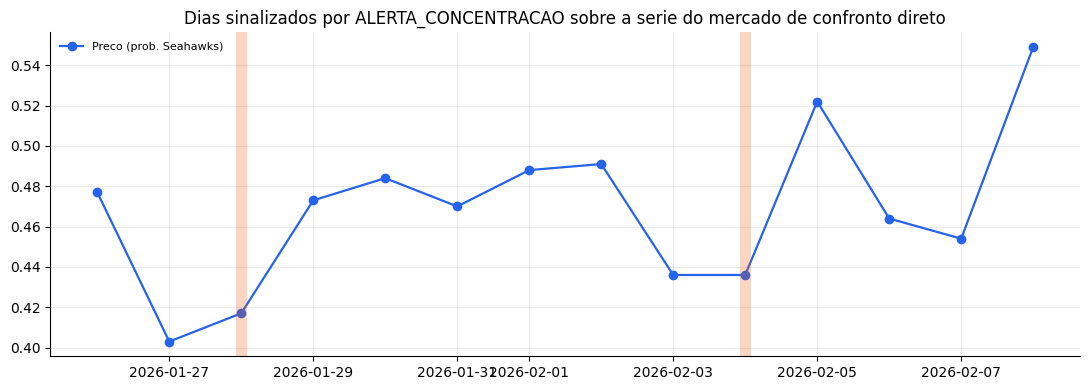

In [14]:
alerta1["na_semana_do_jogo"] = alerta1["trade_date"] >= SEMANA_INI
taxa_concentracao_correta = alerta1["na_semana_do_jogo"].mean()
print(f"ALERTA_CONCENTRACAO -- fracao dos disparos dentro da semana do jogo: {taxa_concentracao_correta:.2f}")

sinais_confronto = alerta2[alerta2["origem"] == "confronto_direto"].copy()
if len(sinais_confronto) == 0:
    print("ALERTA_REVIRAVOLTA (mercado de confronto direto) -- nenhum sinal encontrado na semana do jogo "
          "(coerente com a baixa volatilidade observada nas Etapas 4 e 5).")
else:
    sinais_confronto["direcao_coerente_com_resultado"] = sinais_confronto["tipo_alerta"] == "ALTA_BRUSCA"
    taxa_coerente = sinais_confronto["direcao_coerente_com_resultado"].mean()
    print(f"ALERTA_REVIRAVOLTA (mercado de confronto direto) -- fracao na direcao do resultado final: {taxa_coerente:.2f}")

print()
print("Sinais na reversao pre-confronto (25-26/01), so para contexto:")
print(alerta2[alerta2["origem"] == "futuros_pre_confronto"][["market_id", "hora_atual", "variacao_1h"]].to_string(index=False))

fig, ax = plt.subplots()
ax.plot(serie["trade_date"], serie["preco_medio"], color=COR_PRECO, lw=1.6, marker="o", label="Preco (prob. Seahawks)")
for _, row in alerta1.iterrows():
    ax.axvline(row["trade_date"], color=COR_DESTAQUE, alpha=0.25, lw=8)
ax.set_title("Dias sinalizados por ALERTA_CONCENTRACAO sobre a serie do mercado de confronto direto")
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()


## Síntese

**Concentração.** A confiança implícita não cresceu de forma consistente conforme o jogo se
aproximou (Etapa 4: média de 0,09 antes da semana do jogo, caindo para 0,08 na semana do jogo). O
`ALERTA_CONCENTRACAO` (com limiar relativo, top 30% da distribuição) disparou em apenas 2 dias,
espalhados e não concentrados no fim da janela: 28/01 (confiança 0,166, ainda na fase inicial pós-
abertura do mercado) e 04/02 (confiança 0,128, dentro da semana do jogo, mas isolado, ou seja, não faz
parte de uma tendência sustentada de alta). Apenas metade dos disparos (1 de 2) caiu dentro da semana
do jogo, não há evidência de concentração crescente perto do fechamento.  
  
**Volatilidade.** O desvio padrão móvel do preço nos dias finais (Etapa 5: média 0,0376) foi maior,
não menor, do que na baseline logo após a abertura do mercado (0,0338), o oposto do previsto pela
hipótese. O padrão observado foi de calmaria na véspera (07/02) seguida de disparo no próprio dia do
jogo (08/02), coincidindo com a explosão de volume vista na etapa 3.  
  
**Reviravolta.** O `ALERTA_REVIRAVOLTA` encontrou 4 sinais horários, e todos vieram da fonte
`futuros_pre_confronto` (25-26/01), nenhum sinal disparou na semana do jogo (01-08/02), mercado de
confronto direto. Os 4 sinais são exatamente a sequência de eventos real: os Patriots sobem (+0,095) às
23h UTC de 25/01, quando vencem a AFC Championship; os Seahawks sobem em 3 passos (+0,098, +0,116,
+0,084) entre 01h-03h UTC de 26/01, ao longo da vitória na NFC Championship. Ou seja: a parte da
hipótese sobre "reviravolta perto do fechamento por crítica especializada ou vazamento" não se
confirma,mas o mecanismo geral por trás da hipótese (mercado reage de forma abrupta a informação
nova e relevante) se confirma com clareza, só que no evento errado da linha do tempo: o resultado
real dos jogos eliminatórios de conferência, não uma notícia de bastidor perto do Super Bowl em si.  
  
**Limitações.** Um salto de preço horário não comprova, por si só, que uma crítica específica ou um
vazamento causou aquele movimento, mas, no caso da reversão de 25-26/01, a causa é excepcionalmente
bem documentada (o resultado público e verificável dos dois jogos de conferência), o que torna esse
achado mais sólido que um "salto sem explicação". Já os 2 dias sinalizados pelo `ALERTA_CONCENTRACAO`
usam um limiar relativo (percentil da própria série) justamente porque a confiança implícita deste
mercado nunca foi alta em termos absolutos (máximo observado ~0,20). Isso significa que o alerta
sinaliza "os dias relativamente mais decididos dentro de um mercado que, no geral, ficou perto do
empate técnico a maior parte do tempo", não "dias de forte convicção" em sentido absoluto. Por fim, o
`end_date` do mercado de confronto direto (08/02 23:30 UTC) coincide com o kickoff, não com o fim da
partida. A Etapa 6 confirmou negociações até 06h UTC de 09/02, ou seja, o mercado continuou ativo
horas depois do jogo terminar; esta análise cobriu só o período pré-jogo.



